<a href="https://colab.research.google.com/github/purpllblue/analisis-sentimen-brimo/blob/main/Analisis_Sentimen_Ulasan_Aplikasi_BRI_Mobile_(Rating_Based_dan_InSet_Lexicon_Based).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.pipeline import Pipeline                     # untuk menggabungkan TF-IDF dan model
from sklearn.model_selection import GridSearchCV, KFold   # untuk tuning parameter + cross validation
from sklearn.feature_extraction.text import TfidfVectorizer  # untuk ubah teks jadi numerik
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# **Load Data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataskripsi/scrap_brimo.csv')
df

,userName,score,at,content
0,Pengguna Google,2,2026-04-01 17:22:26,"ga bisa screenshot,aneh"
1,Pengguna Google,5,2026-04-01 17:19:04,sangat membantu
2,Pengguna Google,5,2026-04-01 17:13:30,sangat membantu
3,Pengguna Google,5,2026-04-01 17:08:11,💖💖💖
4,Pengguna Google,2,2026-04-01 16:50:08,"gjelas gbisa buka krna ""koneksi internet kuran..."
...,...,...,...,...
69995,Pengguna Google,5,2025-07-24 22:42:24,cukup membantu saya bekerja🙏
69996,Pengguna Google,5,2025-07-24 22:35:34,oke
69997,Pengguna Google,5,2025-07-24 22:30:23,mantap
69998,Pengguna Google,5,2025-07-24 22:26:55,top markotop


In [ ]:
len(df.index)

70000

In [ ]:
# ganti nama kolom
df = df[['userName', 'score', 'at', 'content']].copy()
df.columns = ['Nama', 'Rating', 'Tanggal', 'Review']
df

,Nama,Rating,Tanggal,Review
0,Pengguna Google,2,2026-04-01 17:22:26,"ga bisa screenshot,aneh"
1,Pengguna Google,5,2026-04-01 17:19:04,sangat membantu
2,Pengguna Google,5,2026-04-01 17:13:30,sangat membantu
3,Pengguna Google,5,2026-04-01 17:08:11,💖💖💖
4,Pengguna Google,2,2026-04-01 16:50:08,"gjelas gbisa buka krna ""koneksi internet kuran..."
...,...,...,...,...
69995,Pengguna Google,5,2025-07-24 22:42:24,cukup membantu saya bekerja🙏
69996,Pengguna Google,5,2025-07-24 22:35:34,oke
69997,Pengguna Google,5,2025-07-24 22:30:23,mantap
69998,Pengguna Google,5,2025-07-24 22:26:55,top markotop


In [ ]:
# ambil ulasan rentang 24 Januari - 24 Maret 2026
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

start_date = '2026-01-24'
end_date = '2026-03-25'

df2 = df[(df['Tanggal'] >= start_date) & (df['Tanggal'] <= end_date)]
print(df2.shape)

df2.to_csv("data_skripsi.csv", index=False)

(17272, 4)


In [ ]:
df2 = pd.read_csv('data_skripsi.csv')
df2

,Nama,Rating,Tanggal,Review
0,Pengguna Google,5,2026-03-24 23:56:55,ok
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus
...,...,...,...,...
17267,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏
17268,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰
17269,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...
17270,Pengguna Google,5,2026-01-24 00:06:01,bagus sangat membantu


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17272 entries, 0 to 17271
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Nama     17272 non-null  object
 1   Rating   17272 non-null  int64 
 2   Tanggal  17272 non-null  object
 3   Review   17272 non-null  object
dtypes: int64(1), object(3)
memory usage: 539.9+ KB


In [ ]:
# cek data duplikat
df2.duplicated(subset=['Review']).sum()

np.int64(5895)

In [ ]:
# drop data duplikat
df2.drop_duplicates(subset='Review', keep = 'first', inplace=True)
df2.reset_index(drop=True, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11377 entries, 0 to 11376
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Nama     11377 non-null  object
 1   Rating   11377 non-null  int64 
 2   Tanggal  11377 non-null  object
 3   Review   11377 non-null  object
dtypes: int64(1), object(3)
memory usage: 355.7+ KB


In [ ]:
# cek missing value
print(df2.isnull().sum())

Nama       0
Rating     0
Tanggal    0
Review     0
dtype: int64


# **Preprocessing**

In [ ]:
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus
...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...


### *Cleaning*

In [ ]:
# hapus url
def remove_URL(brimo):
  if brimo is not None and isinstance(brimo, str):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', brimo)
  else:
    return brimo

# hapus html
def remove_html(brimo):
  if brimo is not None and isinstance(brimo, str):
    html = re.compile(r'<.*?>')
    return html.sub(r'', brimo)
  else:
    return brimo

# hapus emoji
def remove_emoji(brimo):
  if brimo is not None and isinstance(brimo, str):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F" # emoticons
        u"\U0001F300-\U0001F5FF" # symbols & pictographs
        u"\U0001F680-\U0001F6FF" # transport & map symbols
        u"\U0001F700-\U0001F77F" # alchemical symbols
        u"\U0001f780-\U0001f7ff" # geometric shapes extended
        u"\U0001F800-\U0001F8FF" # supplemental arrows-c
        u"\U0001F900-\U0001F9FF" # supplemental symbols and pictographs
        u"\U0001FA00-\U0001FA6F" # chess symbols
        u"\U0001FA70-\U0001FAFF" # symbols and pictographs extended-a
        u"\U0001F004-\U0001F0CF" # additional emoticons
        u"\U0001F170-\U0001F251" # flags
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', brimo)
  else:
    return brimo

# hapus hashtag dan mention
def remove_hashtag_mention(brimo):
  if brimo is not None and isinstance(brimo, str):
    brimo = re.sub(r'#\w+', '', brimo)
    brimo = re.sub(r'@\w+', '', brimo)
  return brimo

# hapus simbol
def remove_symbols(brimo):
  if brimo is not None and isinstance(brimo, str):
    brimo = re.sub(r'[^a-zA-Z0-9\s]', ' ', brimo)
  return brimo

# hapus angka
def remove_numbers(brimo):
  if brimo is not None and isinstance(brimo, str):
    brimo = re.sub(r'\d', '', brimo)
  return brimo

df2['cleaning'] = df2['Review'].apply(remove_URL) # hapus url/link
df2['cleaning'] = df2['cleaning'].apply(remove_html) # hapus html
df2['cleaning'] = df2['cleaning'].apply(remove_emoji) # hapus emoji
df2['cleaning'] = df2['cleaning'].apply(remove_hashtag_mention) # hapus hashtag dan mention
df2['cleaning'] = df2['cleaning'].apply(remove_symbols) # hapus tanda baca dan simbol
df2['cleaning'] = df2['cleaning'].apply(remove_numbers) # hapus angka
df2['cleaning'] = df2['cleaning'].str.replace(r'\s+', ' ', regex=True).str.strip() # ubah spasi ganda jadi 1 spasi dan hapus spasi di awal/akhir
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus
...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...


### *Case Folding*

In [ ]:
def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text
df2['case_folding'] = df2['cleaning'].apply(case_folding)
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus
...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...


### *Normalisasi*

In [ ]:
# kamus tidak baku
kamus_data = pd.read_csv('/content/drive/MyDrive/dataskripsi/slangwords.csv')
kamus_data

,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0
...,...,...,...,...,...,...,...
15001,gataunya,enggak taunya,0,Ini kaya nenek2 ya beb gataunya agnezz @yugime...,akronim,0,0
15002,gtau,enggak tau,0,Stidaknya mrka may berkarya Dan berusaha yg tr...,akronim,abreviasi,0
15003,gatau,enggak tau,0,Ih gatau malu,akronim,0,0
15004,fans2,fan-fan,0,Jkt48 adalah tempat di mana sesama fans saling...,reduplikasi,naturalisasi,0


In [ ]:
kamus_slang = dict(zip(kamus_data['slang'], kamus_data['formal']))
print(f"Total kata slang: {len(kamus_slang)}")

Total kata slang: 4331


In [ ]:
def normalisasi(text):
    if not isinstance(text, str):
        return text
    words = text.split()
    words = [kamus_slang.get(w, w) for w in words]
    return ' '.join(words)

df2['normalisasi'] = df2['case_folding'].apply(normalisasi)
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding,normalisasi
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok,ok
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan,memudahkan
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus
...,...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar,semoga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi,memudahkan semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tidak di acc di ...


### *Tokenizing*

In [ ]:
def tokenize(text):
  tokens = text.split()
  return tokens
df2['tokenize'] = df2['normalisasi'].apply(tokenize)
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding,normalisasi,tokenize
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok,ok,[ok]
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan,memudahkan,[memudahkan]
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,"[transfer, sangat, mudah, dari, saya, gaptek, ..."
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,"[pelayanan, bsgus]"
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,"[sangat, mudah, n, bangus]"
...,...,...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,"[sangat, membantun, dan, praktis]"
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar,semoga rejeki lancar,"[semoga, rejeki, lancar]"
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi,memudahkan semua transaksi,"[memudahkan, semua, transaksi]"
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tidak di acc di ...,"[sdikit, demi, sedikit, transaksi, tidak, di, ..."


### *Stopword Removal*

In [ ]:
# nltk.download('stopwords')
# stop_words = set(stopwords.words('indonesian'))

In [ ]:
factory = StopWordRemoverFactory()
stop_words = set(factory.get_stop_words())

# hapus kata penting dari stopword
for word in ['tidak', 'bukan', 'kurang']:
    stop_words.discard(word)

In [ ]:
def remove_stopwords(text):
  return [word for word in text if word not in stop_words]
df2['stopword_removal'] = df2['tokenize'].apply(remove_stopwords)
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding,normalisasi,tokenize,stopword_removal
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok,ok,[ok],[]
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan,memudahkan,[memudahkan],[memudahkan]
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,"[transfer, sangat, mudah, dari, saya, gaptek, ...","[transfer, sangat, mudah, gaptek, menjadi, sat..."
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,"[pelayanan, bsgus]","[pelayanan, bsgus]"
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,"[sangat, mudah, n, bangus]","[sangat, mudah, n, bangus]"
...,...,...,...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,"[sangat, membantun, dan, praktis]","[sangat, membantun, praktis]"
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar,semoga rejeki lancar,"[semoga, rejeki, lancar]","[semoga, rejeki, lancar]"
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi,memudahkan semua transaksi,"[memudahkan, semua, transaksi]","[memudahkan, semua, transaksi]"
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tidak di acc di ...,"[sdikit, demi, sedikit, transaksi, tidak, di, ...","[sdikit, sedikit, transaksi, tidak, acc, arahk..."


### *Stemming*

In [ ]:
# from nltk.stem import PorterStemmer
# from nltk.stem.snowball import SnowballStemmer

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    if not isinstance(text, list):
        return ''
    return ' '.join([stemmer.stem(word) for word in text])
df2['stemming'] = df2['stopword_removal'].apply(stem_text)
df2

,Nama,Rating,Tanggal,Review,cleaning,case_folding,normalisasi,tokenize,stopword_removal,stemming
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok,ok,[ok],[],
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan,memudahkan,[memudahkan],[memudahkan],mudah
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,"[transfer, sangat, mudah, dari, saya, gaptek, ...","[transfer, sangat, mudah, gaptek, menjadi, sat...",transfer sangat mudah gaptek jadi satset
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,"[pelayanan, bsgus]","[pelayanan, bsgus]",layan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,"[sangat, mudah, n, bangus]","[sangat, mudah, n, bangus]",sangat mudah n bangus
...,...,...,...,...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,"[sangat, membantun, dan, praktis]","[sangat, membantun, praktis]",sangat bantun praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar,semoga rejeki lancar,"[semoga, rejeki, lancar]","[semoga, rejeki, lancar]",moga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi,memudahkan semua transaksi,"[memudahkan, semua, transaksi]","[memudahkan, semua, transaksi]",mudah semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tidak di acc di ...,"[sdikit, demi, sedikit, transaksi, tidak, di, ...","[sdikit, sedikit, transaksi, tidak, acc, arahk...",sdikit sedikit transaksi tidak acc arah adu ma...


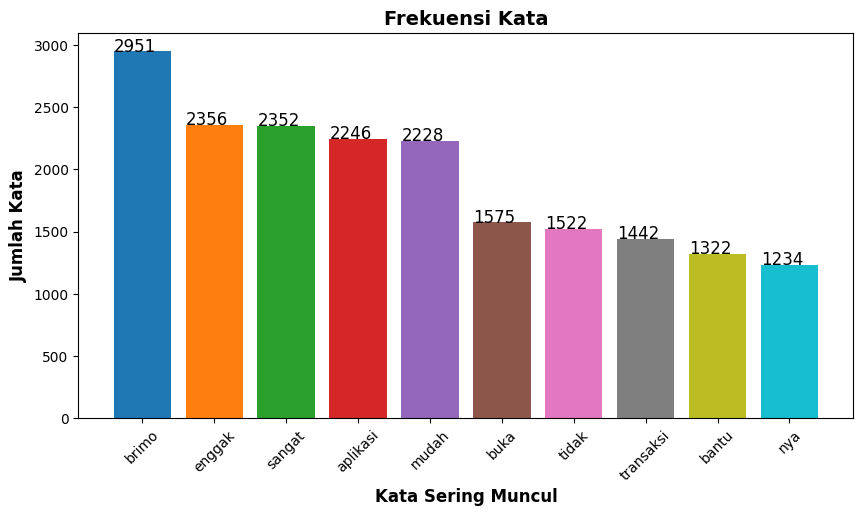

In [ ]:
# visualisasi frekuensi kata muncul
text = " ".join(df2['stemming'])
tokens = text.split()
word_counts = Counter(tokens)

top_word = word_counts.most_common(10)
word, count = zip(*top_word)

# warna
warna = plt.cm.tab10(range(len(word)))
plt.figure(figsize=(10, 5))
bars = plt.bar(word, count, color=warna)
plt.xlabel("Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
  plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')
plt.show()

In [ ]:
df2.to_csv('Hasil_Preprocessing.csv', encoding='utf8', index=False);

# **Labeling**

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/dataskripsi/Hasil_Preprocessing.csv')
df3

,Nama,Rating,Tanggal,Review,cleaning,case_folding,normalisasi,tokenize,stopword_removal,stemming
0,Pengguna Google,5,2026-03-24 23:56:55,ok,ok,ok,ok,['ok'],[],NaN
1,Pengguna Google,5,2026-03-24 23:42:43,memudahkan,memudahkan,memudahkan,memudahkan,['memudahkan'],['memudahkan'],mudah
2,Pengguna Google,5,2026-03-24 23:39:19,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,transfer sangat mudah dari saya gaptek menjadi...,"['transfer', 'sangat', 'mudah', 'dari', 'saya'...","['transfer', 'sangat', 'mudah', 'gaptek', 'men...",transfer sangat mudah gaptek jadi satset
3,Pengguna Google,4,2026-03-24 23:28:10,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,pelayanan bsgus,"['pelayanan', 'bsgus']","['pelayanan', 'bsgus']",layan bsgus
4,Pengguna Google,5,2026-03-24 23:25:52,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,sangat mudah n bangus,"['sangat', 'mudah', 'n', 'bangus']","['sangat', 'mudah', 'n', 'bangus']",sangat mudah n bangus
...,...,...,...,...,...,...,...,...,...,...
11372,Pengguna Google,5,2026-01-24 00:18:53,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,sangat membantun dan praktis,"['sangat', 'membantun', 'dan', 'praktis']","['sangat', 'membantun', 'praktis']",sangat bantun praktis
11373,Pengguna Google,5,2026-01-24 00:18:41,semoga rejeki lancar 🙏,semoga rejeki lancar,semoga rejeki lancar,semoga rejeki lancar,"['semoga', 'rejeki', 'lancar']","['semoga', 'rejeki', 'lancar']",moga rejeki lancar
11374,Pengguna Google,5,2026-01-24 00:13:06,memudahkan semua transaksi 🫰,memudahkan semua transaksi,memudahkan semua transaksi,memudahkan semua transaksi,"['memudahkan', 'semua', 'transaksi']","['memudahkan', 'semua', 'transaksi']",mudah semua transaksi
11375,Pengguna Google,3,2026-01-24 00:12:01,sdikit demi sedikit transaksi tdk di acc... di...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tdk di acc di ar...,sdikit demi sedikit transaksi tidak di acc di ...,"['sdikit', 'demi', 'sedikit', 'transaksi', 'ti...","['sdikit', 'sedikit', 'transaksi', 'tidak', 'a...",sdikit sedikit transaksi tidak acc arah adu ma...


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11377 entries, 0 to 11376
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Nama              11377 non-null  object
 1   Rating            11377 non-null  int64 
 2   Tanggal           11377 non-null  object
 3   Review            11377 non-null  object
 4   cleaning          11322 non-null  object
 5   case_folding      11322 non-null  object
 6   normalisasi       11322 non-null  object
 7   tokenize          11377 non-null  object
 8   stopword_removal  11377 non-null  object
 9   stemming          11307 non-null  object
dtypes: int64(1), object(9)
memory usage: 889.0+ KB


In [ ]:
print(df3.isnull().sum())

Nama                 0
Rating               0
Tanggal              0
Review               0
cleaning            55
case_folding        55
normalisasi         55
tokenize             0
stopword_removal     0
stemming            70
dtype: int64


In [ ]:
df3 = df3.dropna().reset_index(drop=True)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11307 entries, 0 to 11306
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Nama              11307 non-null  object
 1   Rating            11307 non-null  int64 
 2   Tanggal           11307 non-null  object
 3   Review            11307 non-null  object
 4   cleaning          11307 non-null  object
 5   case_folding      11307 non-null  object
 6   normalisasi       11307 non-null  object
 7   tokenize          11307 non-null  object
 8   stopword_removal  11307 non-null  object
 9   stemming          11307 non-null  object
dtypes: int64(1), object(9)
memory usage: 883.5+ KB


In [ ]:
df4 = df3[['Rating','stemming']].copy()
df4

,Rating,stemming
0,5,mudah
1,5,transfer sangat mudah gaptek jadi satset
2,4,layan bsgus
3,5,sangat mudah n bangus
4,5,suka potong rbu satu bulan enggak tau
...,...,...
11302,5,sangat bantun praktis
11303,5,moga rejeki lancar
11304,5,mudah semua transaksi
11305,3,sdikit sedikit transaksi tidak acc arah adu ma...


## *InSet Lexicon-based* (modif)


In [ ]:
positif = pd.read_csv('/content/drive/MyDrive/dataskripsi/positive.tsv',
                      sep='\t', header=None, names=['word', 'weight'])
positif

,word,weight
0,word,weight
1,hai,3
2,merekam,2
3,ekstensif,3
4,paripurna,1
...,...,...
3605,melarikan,3
3606,vakansi,3
3607,spesial,4
3608,asrama,3


In [ ]:
negatif = pd.read_csv('/content/drive/MyDrive/dataskripsi/negative_modif.tsv',
                      sep='\t', header=None, names=['word', 'weight'])
negatif

,word,weight
0,word,weight
1,putus tali gantung,-2
2,gelebah,-2
3,gobar hati,-2
4,tersentuh (perasaan),-1
...,...,...
6605,kantong kering,-4
6606,penggaruk,-3
6607,senewen,-4
6608,menetapkan,-5


In [ ]:
# hapus baris pertama
positif = positif.drop(0).reset_index(drop=True)
negatif = negatif.drop(0).reset_index(drop=True)

# ubah weight jadi numerik
positif['weight'] = pd.to_numeric(positif['weight'])
negatif['weight'] = pd.to_numeric(negatif['weight'])

# membuat dictionary
pos_dict = dict(zip(positif['word'], positif['weight']))
neg_dict = dict(zip(negatif['word'], negatif['weight']))

def label_sentimen(teks):
    if not isinstance(teks, str):
        return '', '', 0, 'negatif'

    kata_list = teks.split()
    kata_terdeteksi = []
    bobot_kata = []
    skor = 0

    for kata in kata_list:
        if kata in pos_dict:
            skor += pos_dict[kata]
            kata_terdeteksi.append(kata)
            bobot_kata.append(pos_dict[kata])

        elif kata in neg_dict:
            skor += neg_dict[kata]
            kata_terdeteksi.append(kata)
            bobot_kata.append(neg_dict[kata])

    label = 'positif' if skor > 0 else 'negatif'

    return (
        teks,
        ', '.join(kata_terdeteksi),
        ', '.join(map(str, bobot_kata)),
        skor,
        label
    )

In [ ]:
df_inset = df4['stemming'].apply(
    lambda x: pd.Series(label_sentimen(x))
)

df_inset.columns = [
    'stemming',
    'kata_terdeteksi',
    'bobot_kata',
    'score_mod',
    'Label_Inset_mod'
]

df_inset

,stemming,kata_terdeteksi,bobot_kata,score_mod,Label_Inset_mod
0,mudah,mudah,4,4,positif
1,transfer sangat mudah gaptek jadi satset,"sangat, mudah, jadi","3, 4, 1",8,positif
2,layan bsgus,layan,2,2,positif
3,sangat mudah n bangus,"sangat, mudah","3, 4",7,positif
4,suka potong rbu satu bulan enggak tau,"suka, potong, satu, bulan, tau","3, -2, 3, -1, -4",-1,negatif
...,...,...,...,...,...
11302,sangat bantun praktis,"sangat, praktis","3, 4",7,positif
11303,moga rejeki lancar,"moga, rejeki, lancar","1, 4, 4",9,positif
11304,mudah semua transaksi,"mudah, semua, transaksi","4, -3, 4",5,positif
11305,sdikit sedikit transaksi tidak acc arah adu ma...,"sedikit, transaksi, tidak, arah, adu, muncul, ...","-4, 4, -5, 1, -3, 1, -3, 4, -3",-8,negatif


In [ ]:
df_inset.to_csv('Hasil_Inset_mod.csv', encoding='utf8', index=False)

## *Inset Lexicon*


In [ ]:
positif2 = pd.read_csv('/content/drive/MyDrive/dataskripsi/positive.tsv',
                      sep='\t', header=None, names=['word', 'weight'])
positif2

,word,weight
0,word,weight
1,hai,3
2,merekam,2
3,ekstensif,3
4,paripurna,1
...,...,...
3605,melarikan,3
3606,vakansi,3
3607,spesial,4
3608,asrama,3


In [ ]:
negatif2 = pd.read_csv('/content/drive/MyDrive/dataskripsi/negative.tsv',
                      sep='\t', header=None, names=['word', 'weight'])
negatif2

,word,weight
0,word,weight
1,putus tali gantung,-2
2,gelebah,-2
3,gobar hati,-2
4,tersentuh (perasaan),-1
...,...,...
6605,kantong kering,-4
6606,penggaruk,-3
6607,senewen,-4
6608,menetapkan,-5


In [ ]:
# hapus baris pertama
positif2 = positif2.drop(0).reset_index(drop=True)
negatif2 = negatif2.drop(0).reset_index(drop=True)

# ubah weight jadi numerik
positif2['weight'] = pd.to_numeric(positif2['weight'])
negatif2['weight'] = pd.to_numeric(negatif2['weight'])

# membuat dictionary
pos_dict2 = dict(zip(positif2['word'], positif2['weight']))
neg_dict2 = dict(zip(negatif2['word'], negatif2['weight']))

def label_sentimen2(teks):
    if not isinstance(teks, str):
        return '', '', 0, 'negatif'

    kata_list = teks.split()
    kata_terdeteksi = []
    bobot_kata = []
    skor = 0

    for kata in kata_list:
        if kata in pos_dict2:
            skor += pos_dict2[kata]
            kata_terdeteksi.append(kata)
            bobot_kata.append(pos_dict2[kata])

        elif kata in neg_dict2:
            skor += neg_dict2[kata]
            kata_terdeteksi.append(kata)
            bobot_kata.append(neg_dict2[kata])

    label = 'positif' if skor > 0 else 'negatif'

    return (
        teks,
        ', '.join(kata_terdeteksi),
        ', '.join(map(str, bobot_kata)),
        skor,
        label
    )

In [ ]:
df_inset2 = df4['stemming'].apply(
    lambda x: pd.Series(label_sentimen2(x))
)

df_inset2.columns = [
    'stemming',
    'kata_terdeteksi',
    'bobot_kata',
    'score',
    'Label_Inset'
]

df_inset2

,stemming,kata_terdeteksi,bobot_kata,score,Label_Inset
0,mudah,mudah,4,4,positif
1,transfer sangat mudah gaptek jadi satset,"sangat, mudah, jadi","3, 4, 1",8,positif
2,layan bsgus,layan,2,2,positif
3,sangat mudah n bangus,"sangat, mudah","3, 4",7,positif
4,suka potong rbu satu bulan enggak tau,"suka, potong, satu, bulan, tau","3, -2, 3, -1, -4",-1,negatif
...,...,...,...,...,...
11302,sangat bantun praktis,"sangat, praktis","3, 4",7,positif
11303,moga rejeki lancar,"moga, rejeki, lancar","1, 4, 4",9,positif
11304,mudah semua transaksi,"mudah, semua, transaksi","4, -3, 4",5,positif
11305,sdikit sedikit transaksi tidak acc arah adu ma...,"sedikit, transaksi, tidak, arah, adu, muncul, ...","-4, 4, -5, 1, -3, 1, -3, 4, -3",-8,negatif


In [ ]:
df_inset2.to_csv('Hasil_Inset.csv', encoding='utf8', index=False)

## *Rating-based*

In [ ]:
def label_rating(rating):
    if rating > 3:
        return 'positif'
    else:
        return 'negatif'

In [ ]:
df_rating = df4[['Rating', 'stemming']].copy()
df_rating['Label_Rating'] = df_rating['Rating'].apply(label_rating)
df_rating

,Rating,stemming,Label_Rating
0,5,mudah,positif
1,5,transfer sangat mudah gaptek jadi satset,positif
2,4,layan bsgus,positif
3,5,sangat mudah n bangus,positif
4,5,suka potong rbu satu bulan enggak tau,positif
...,...,...,...
11302,5,sangat bantun praktis,positif
11303,5,moga rejeki lancar,positif
11304,5,mudah semua transaksi,positif
11305,3,sdikit sedikit transaksi tidak acc arah adu ma...,negatif


In [ ]:
df_rating.to_csv('Hasil_Rating.csv', encoding='utf8', index=False)

## Hasil Sentimen

In [ ]:
df_hasil = df4.copy()

df_hasil[[
    'stemming',
    'kata_terdeteksi',
    'bobot_kata',
    'Score_mod',
    'Label_Inset_mod'
]] = df_hasil['stemming'].apply(
    lambda x: pd.Series(label_sentimen(x))
)

df_hasil[[
    'stemming',
    'kata_terdeteksi',
    'bobot_kata',
    'Score',
    'Label_Inset'
]] = df_hasil['stemming'].apply(
    lambda x: pd.Series(label_sentimen2(x))
)

df_hasil['Label_Rating'] = df_hasil['Rating'].apply(label_rating)

# tampilkan kolom yang ingin dibandingkan
df_hasil = df_hasil[[
    'stemming',
    'Score',
    'Score_mod',
    'Rating',
    'Label_Inset',
    'Label_Inset_mod',
    'Label_Rating'
]]

df_hasil

,stemming,Score,Score_mod,Rating,Label_Inset,Label_Inset_mod,Label_Rating
0,mudah,4,4,5,positif,positif,positif
1,transfer sangat mudah gaptek jadi satset,8,8,5,positif,positif,positif
2,layan bsgus,2,2,4,positif,positif,positif
3,sangat mudah n bangus,7,7,5,positif,positif,positif
4,suka potong rbu satu bulan enggak tau,-1,-1,5,negatif,negatif,positif
...,...,...,...,...,...,...,...
11302,sangat bantun praktis,7,7,5,positif,positif,positif
11303,moga rejeki lancar,9,9,5,positif,positif,positif
11304,mudah semua transaksi,5,5,5,positif,positif,positif
11305,sdikit sedikit transaksi tidak acc arah adu ma...,-8,-8,3,negatif,negatif,negatif


In [ ]:
jumlah = pd.DataFrame({
    'Label_Inset': df_hasil['Label_Inset'].value_counts(),
    'Label_Rating': df_hasil['Label_Rating'].value_counts(),
    'Label_Inset_mod': df_hasil['Label_Inset_mod'].value_counts()
})

jumlah = jumlah.reindex(['positif', 'negatif'])

persen = pd.DataFrame({
    'Label_Inset': (df_hasil['Label_Inset'].value_counts(normalize=True)*100).round(2),
    'Label_Rating': (df_hasil['Label_Rating'].value_counts(normalize=True)*100).round(2),
    'Label_Inset_mod': (df_hasil['Label_Inset_mod'].value_counts(normalize=True)*100).round(2)
})

# gabung jadi format jumlah (persen)
hasil = jumlah.astype(str)+'('+persen.astype(str)+'%)'
hasil = hasil.reindex(['positif', 'negatif'])
hasil

,Label_Inset,Label_Rating,Label_Inset_mod
positif,7538(66.67%),7987(70.64%),7916(70.01%)
negatif,3769(33.33%),3320(29.36%),3391(29.99%)


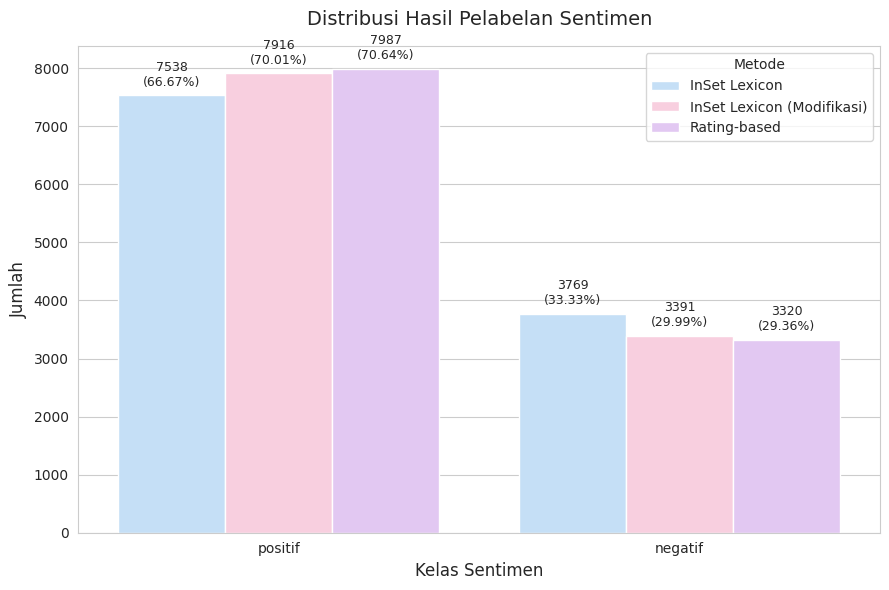

In [ ]:
sns.set_style("whitegrid")

sentiment_inset = df_hasil['Label_Inset'].value_counts()
sentiment_mod = df_hasil['Label_Inset_mod'].value_counts()
sentiment_rating = df_hasil['Label_Rating'].value_counts()

sentiment_count = pd.DataFrame({
    'Label_Inset': sentiment_inset,
    'Label_Inset_mod': sentiment_mod,
    'Label_Rating': sentiment_rating
}).fillna(0)

sentiment_count = sentiment_count.reset_index().melt(
    id_vars='index',
    var_name='Metode',
    value_name='Jumlah'
).rename(columns={'index': 'Sentimen'})

sentiment_count['Metode'] = sentiment_count['Metode'].replace({
    'Label_Inset': 'InSet Lexicon',
    'Label_Inset_mod': 'InSet Lexicon (Modifikasi)',
    'Label_Rating': 'Rating-based'})

sentiment_count['Sentimen'] = pd.Categorical(
    sentiment_count['Sentimen'],
    categories=['positif', 'negatif'],
    ordered=True)

custom_palette = [
    "#BDE0FE",
    "#FFC8DD",
    "#E4C1F9"
]

fig, ax = plt.subplots(figsize=(9,6))

sns.barplot(
    data=sentiment_count,
    x='Sentimen',
    y='Jumlah',
    hue='Metode',
    palette=custom_palette,
    ax=ax
)

ax.set_title('Distribusi Hasil Pelabelan Sentimen', fontsize=14, pad=15)
ax.set_xlabel('Kelas Sentimen', fontsize=12)
ax.set_ylabel('Jumlah', fontsize=12)
total = len(df_hasil)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + total*0.01,
            f'{int(height)}\n({height/total*100:.2f}%)',
            ha='center',
            va='bottom',
            fontsize=9
        )
ax.legend(title='Metode')
plt.tight_layout()
plt.show()

In [ ]:
df_beda = df_hasil[
    (df_hasil['Label_Inset'] != df_hasil['Label_Rating']) |
    (df_hasil['Label_Inset_mod'] != df_hasil['Label_Rating'])
][[
    'stemming',
    'Score',
    'Label_Inset',
    'Score_mod',
    'Label_Inset_mod',
    'Rating',
    'Label_Rating'
]]

df_beda

,stemming,Score,Label_Inset,Score_mod,Label_Inset_mod,Rating,Label_Rating
4,suka potong rbu satu bulan enggak tau,-1,negatif,-1,negatif,5,positif
9,excellent,0,negatif,0,negatif,5,positif
15,turut aplikasi bagus,-5,negatif,-1,negatif,5,positif
16,jangan pakai bri deh bank belakang inovasi,1,positif,1,positif,1,negatif
21,plisssss bri moo banyak sekali potong annyaa t...,-2,negatif,-2,negatif,5,positif
...,...,...,...,...,...,...,...
11279,nabung bri bikin uang habis tiap bulan uang po...,2,positif,2,positif,1,negatif
11288,wes pokok e jos ra ribet,-1,negatif,-1,negatif,5,positif
11294,update fingerprint tidak kalau mau masuk guna ...,-9,negatif,-9,negatif,4,positif
11299,halo pak brimo hapus donlod tidk jadi lupa use...,-5,negatif,-5,negatif,5,positif


In [ ]:
# Crosstab
ct_inset_rating = pd.crosstab(df_hasil['Label_Inset'], df_hasil['Label_Rating'])
ct_mod_rating = pd.crosstab(df_hasil['Label_Inset_mod'], df_hasil['Label_Rating'])
ct_inset_mod = pd.crosstab(df_hasil['Label_Inset'], df_hasil['Label_Inset_mod'])

beda = pd.DataFrame({
    'Perbandingan': [
        'InSet vs Rating-based',
        'InSet vs Rating-based',
        'InSet Modifikasi vs Rating-based',
        'InSet Modifikasi vs Rating-based',
        'InSet vs InSet Modifikasi',
        'InSet vs InSet Modifikasi'
    ],
    'Metode 1': [
        'Negatif', 'Positif',
        'Negatif', 'Positif',
        'Negatif', 'Positif'
    ],
    'Metode 2': [
        'Positif', 'Negatif',
        'Positif', 'Negatif',
        'Positif', 'Negatif'
    ],
    'Jumlah': [
        ct_inset_rating.loc['negatif', 'positif'],
        ct_inset_rating.loc['positif', 'negatif'],

        ct_mod_rating.loc['negatif', 'positif'],
        ct_mod_rating.loc['positif', 'negatif'],

        ct_inset_mod.loc['negatif', 'positif'],
        ct_inset_mod.loc['positif', 'negatif']
    ]
})

beda

,Perbandingan,Metode 1,Metode 2,Jumlah
0,InSet vs Rating-based,Negatif,Positif,1779
1,InSet vs Rating-based,Positif,Negatif,1330
2,InSet Modifikasi vs Rating-based,Negatif,Positif,1603
3,InSet Modifikasi vs Rating-based,Positif,Negatif,1532
4,InSet vs InSet Modifikasi,Negatif,Positif,378
5,InSet vs InSet Modifikasi,Positif,Negatif,0


In [ ]:
berubah[['Label_Inset','Label_Inset_mod','Label_Rating']] \
    .value_counts() \
    .reset_index(name='Jumlah')

,Label_Inset,Label_Inset_mod,Label_Rating,Jumlah
0,negatif,positif,negatif,202
1,negatif,positif,positif,176


In [ ]:
hasil = pd.DataFrame({
    'Perbandingan': [
        'InSet vs InSet Modifikasi',
        'InSet vs Rating-based',
        'InSet Modifikasi vs Rating-based'
    ],
    'Jumlah Berbeda': [
        len(df_hasil[df_hasil['Label_Inset'] != df_hasil['Label_Inset_mod']]),
        len(df_hasil[df_hasil['Label_Inset'] != df_hasil['Label_Rating']]),
        len(df_hasil[df_hasil['Label_Inset_mod'] != df_hasil['Label_Rating']])
    ]
})

hasil['Persentase (%)'] = (hasil['Jumlah Berbeda'] / len(df_hasil) * 100).round(2)
hasil

,Perbandingan,Jumlah Berbeda,Persentase (%)
0,InSet vs InSet Modifikasi,378,3.34
1,InSet vs Rating-based,3109,27.50
2,InSet Modifikasi vs Rating-based,3135,27.73


In [ ]:
df_hasil.to_csv('Hasil_Labeling.csv', encoding='utf8', index=False)

# **Split Data**

In [ ]:
df5 = pd.read_csv('/content/Hasil_Labeling.csv')
df5

,stemming,Score,Score_mod,Rating,Label_Inset,Label_Inset_mod,Label_Rating
0,mudah,4,4,5,positif,positif,positif
1,transfer sangat mudah gaptek jadi satset,8,8,5,positif,positif,positif
2,layan bsgus,2,2,4,positif,positif,positif
3,sangat mudah n bangus,7,7,5,positif,positif,positif
4,suka potong rbu satu bulan enggak tau,-1,-1,5,negatif,negatif,positif
...,...,...,...,...,...,...,...
11302,sangat bantun praktis,7,7,5,positif,positif,positif
11303,moga rejeki lancar,9,9,5,positif,positif,positif
11304,mudah semua transaksi,5,5,5,positif,positif,positif
11305,sdikit sedikit transaksi tidak acc arah adu ma...,-8,-8,3,negatif,negatif,negatif


In [ ]:
X = df5['stemming']

splits = []
total_split = []

for label_name in ['Label_Inset', 'Label_Inset_mod', 'Label_Rating']:
    y = df5[label_name]

    for i in range(16):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=i,
            stratify=y
        )

        splits.append({
            'label': label_name,
            'iterasi': i + 1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test
        })

        total_split.append({
            'Label': label_name,
            'Iterasi': i + 1,
            'Train Size': len(X_train),
            'Test Size': len(X_test)
        })

df_split = pd.DataFrame(total_split)

print(f"Total split: {len(splits)}")

display(df_split)

Total split: 48


,Label,Iterasi,Train Size,Test Size
0,Label_Inset,1,9045,2262
1,Label_Inset,2,9045,2262
2,Label_Inset,3,9045,2262
3,Label_Inset,4,9045,2262
4,Label_Inset,5,9045,2262
5,Label_Inset,6,9045,2262
6,Label_Inset,7,9045,2262
7,Label_Inset,8,9045,2262
8,Label_Inset,9,9045,2262
9,Label_Inset,10,9045,2262


In [ ]:
X = df5['stemming']

splits = []
total_split = []

for label_name in ['Label_Inset', 'Label_Rating']:
    y = df5[label_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    splits.append({
        'label': label_name,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    })

    total_split.append({
        'Label': label_name,
        'Train Size': len(X_train),
        'Test Size': len(X_test)
    })

df_split = pd.DataFrame(total_split)

print(f"Total split: {len(splits)}")
display(df_split)

Total split: 2


,Label,Train Size,Test Size
0,Label_Inset,9045,2262
1,Label_Rating,9045,2262


In [ ]:
split1 = splits[0]

df_train = pd.DataFrame({
    'stemming': split1['X_train'],
    'Label': split1['y_train']
})

df_test = pd.DataFrame({
    'stemming': split1['X_test'],
    'Label': split1['y_test']
})

In [ ]:
display(df_train)

,stemming,Label
7452,halo min brimo tidak guna nomor rekening nya t...,negatif
1727,brimo nya knapa kok enggak login buka enggak h...,positif
7181,lancar aman cepat,positif
7474,brimo buat urus jadi mudah cepat terimakasih b...,positif
10761,brimo hape tida buka kalo buka seka keluar sen...,negatif
...,...,...
3470,apa apk brimo aku update baru sekarang mala en...,negatif
7024,sistem aman lemah mudah tipu ganti username pa...,positif
1405,bagaimana aplikasi hampir selesai daftar isi d...,positif
9094,pendaftaranya rumit,negatif


In [ ]:
display(df_test)

,stemming,Label
8384,maeeen,negatif
5167,aplikasi lengkap buat smuanya jadi lebih mudah...,positif
9758,transaksi status proses terus tangal tangal ap...,negatif
8613,lama pakai apk brimo baru kali kesel banget ti...,negatif
7442,halo min brimo enggak buka klik brimo terus mu...,negatif
...,...,...
8925,tunggu proses,positif
2645,sering ngeblok putih solusi instal ulang baru ...,positif
6265,login perlu verifikasi mau minta otp ulang eng...,positif
186,maaf sobat brimo tanya mau guna qr tidak dafta...,positif


# **TF-IDF**

In [ ]:
# fitur unik sebelum TF-IDF
text = " ".join(df5['stemming'])
kata_unik = sorted(set(text.split()))

# ubah jadi dataframe
df_kata_unik = pd.DataFrame(
    kata_unik,
    columns=['Fitur_Unik']
)

display(df_kata_unik)

,Fitur_Unik
0,a
1,aa
2,aangat
3,abak
4,abal
...,...
5380,yusernem
5381,yuuuukk
5382,zaman
5383,zonk


In [ ]:
# TF-IDF
tfidf_results = []

for s in splits:
    tfidf = TfidfVectorizer(norm=None)

    # TF-IDF train dan test
    X_train_tfidf = tfidf.fit_transform(s['X_train'])
    X_test_tfidf = tfidf.transform(s['X_test'])

    tfidf_results.append({
        'Label': s['label'],
        'Iterasi': s['iterasi'],
        'Data_Train': X_train_tfidf.shape[0],
        'Data_Test': X_test_tfidf.shape[0],
        'Jumlah_Fitur': X_train_tfidf.shape[1]
    })

# dataframe hasil
df_fitur = pd.DataFrame(tfidf_results)

display(df_fitur)

,Label,Iterasi,Data_Train,Data_Test,Jumlah_Fitur
0,Label_Inset,1,9045,2262,4649
1,Label_Inset,2,9045,2262,4713
2,Label_Inset,3,9045,2262,4637
3,Label_Inset,4,9045,2262,4738
4,Label_Inset,5,9045,2262,4777
5,Label_Inset,6,9045,2262,4709
6,Label_Inset,7,9045,2262,4705
7,Label_Inset,8,9045,2262,4734
8,Label_Inset,9,9045,2262,4714
9,Label_Inset,10,9045,2262,4705


In [ ]:
sample = [51, 107, 155, 2451, 9032]

for split in splits:
    if split['iterasi'] == 1:
        tfidf = TfidfVectorizer()

        # transformasi TF-IDF data latih
        X_train_tfidf = tfidf.fit_transform(
            split['X_train'])

        # dataframe TF-IDF
        df_tfidf = pd.DataFrame(
            X_train_tfidf.toarray(),
            columns=tfidf.get_feature_names_out(),
            index=split['X_train'].index).round(3)

        # ambil dokumen
        doc = [
            idx for idx in sample
            if idx in df_tfidf.index]

        # ambil dokumen sampel
        df_sample = df_tfidf.loc[doc]

        # ambil fitur yang muncul
        df_sample = df_sample.loc[
            :,
            (df_sample != 0).any(axis=0)]

        # hitung DF
        df_values = np.asarray(
            (X_train_tfidf > 0).sum(axis=0)).ravel()

        # dataframe DF dan IDF
        df_info = pd.DataFrame({
            'DF': df_values,
            'IDF': np.round(
                tfidf.idf_, 3)}, index=tfidf.get_feature_names_out())

        # ambil term yang digunakan
        df_info = df_info.loc[
            df_sample.columns]

        # gabungkan hasil
        df_final = pd.concat([
            df_info.T,
            df_sample])

        print(
            f"Label: {split['label']} | "
            f"Iterasi: {split['iterasi']}"
        )

        display(df_final)

# **Hyperparameter Tuning**

## *Naive Bayes*

In [ ]:
# TUNING 1

tuningnb_1 = []

for split in splits:

    # ambil semua data pada iterasi 1
    if split['iterasi'] == 1:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1,2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_1.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_1 = pd.DataFrame(tuningnb_1).round(4)

# simpan csv
tuningnb_1.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_1

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,1,3000,1.0,0.7997
1,Label_Inset_mod,1,3000,1.0,0.8122
2,Label_Rating,1,1000,0.5,0.8591


In [ ]:
# TUNING 2

tuningnb_2 = []

for split in splits:

    # ambil semua data pada iterasi 2
    if split['iterasi'] == 2:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_2.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_2 = pd.DataFrame(tuningnb_2).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_2],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_2

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,2,3000,1.0,0.7996
1,Label_Inset_mod,2,3000,1.0,0.8096
2,Label_Rating,2,2000,0.5,0.8648


In [ ]:
# TUNING 3

tuningnb_3 = []

for split in splits:

    # ambil semua data pada iterasi 3
    if split['iterasi'] == 3:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_3.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_3 = pd.DataFrame(tuningnb_3).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_3],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_3

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,3,3000,1.0,0.7961
1,Label_Inset_mod,3,3000,1.0,0.8099
2,Label_Rating,3,2000,0.5,0.8620


In [ ]:
# TUNING 4

tuningnb_4 = []

for split in splits:

    # ambil semua data pada iterasi 4
    if split['iterasi'] == 4:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_4.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_4 = pd.DataFrame(tuningnb_4).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_4],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_4

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,4,3000,1.0,0.7989
1,Label_Inset_mod,4,3000,1.0,0.8084
2,Label_Rating,4,1000,0.5,0.8639


In [ ]:
# TUNING 5

tuningnb_5 = []

for split in splits:

    # ambil semua data pada iterasi 5
    if split['iterasi'] == 5:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_5.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_5 = pd.DataFrame(tuningnb_5).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_5],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_5

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,5,3000,1.0,0.8010
1,Label_Inset_mod,5,3000,0.5,0.8078
2,Label_Rating,5,2000,0.5,0.8596


In [ ]:
# TUNING 6

tuningnb_6 = []

for split in splits:

    # ambil semua data pada iterasi 6
    if split['iterasi'] == 6:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_6.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_6 = pd.DataFrame(tuningnb_6).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_6],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_6

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,6,3000,1.0,0.8034
1,Label_Inset_mod,6,3000,1.0,0.8102
2,Label_Rating,6,2000,0.5,0.8591


In [ ]:
# TUNING 7

tuningnb_7 = []

for split in splits:

    # ambil semua data pada iterasi 7
    if split['iterasi'] == 7:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_7.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_7 = pd.DataFrame(tuningnb_7).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_7],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_7

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,7,3000,1.0,0.7983
1,Label_Inset_mod,7,3000,1.0,0.8109
2,Label_Rating,7,1000,0.1,0.8619


In [ ]:
# TUNING 8

tuningnb_8 = []

for split in splits:

    # ambil semua data pada iterasi 8
    if split['iterasi'] == 8:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_8.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_8 = pd.DataFrame(tuningnb_8).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_8],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_8

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,8,3000,1.0,0.7986
1,Label_Inset_mod,8,3000,0.5,0.8091
2,Label_Rating,8,1000,0.5,0.8610


In [ ]:
# TUNING 9

tuningnb_9 = []

for split in splits:

    # ambil semua data pada iterasi 9
    if split['iterasi'] == 9:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_9.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_9 = pd.DataFrame(tuningnb_9).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_9],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_9

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,9,3000,1.0,0.8009
1,Label_Inset_mod,9,3000,1.0,0.8072
2,Label_Rating,9,2000,0.5,0.8603


In [ ]:
# TUNING 10

tuningnb_10 = []

for split in splits:

    # ambil semua data pada iterasi 10
    if split['iterasi'] == 10:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_10.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_10 = pd.DataFrame(tuningnb_10).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_10],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_10

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,10,3000,1,0.8031
1,Label_Inset_mod,10,3000,1,0.8094
2,Label_Rating,10,1000,1,0.8617


In [ ]:
# TUNING 11

tuningnb_11 = []

for split in splits:

    # ambil semua data pada iterasi 11
    if split['iterasi'] == 11:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_11.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_11 = pd.DataFrame(tuningnb_11).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_11],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_11

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,11,3000,1.0,0.8013
1,Label_Inset_mod,11,3000,1.0,0.8108
2,Label_Rating,11,2000,0.5,0.8629


In [ ]:
# TUNING 12

tuningnb_12 = []

for split in splits:

    # ambil semua data pada iterasi 12
    if split['iterasi'] == 12:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_12.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_12 = pd.DataFrame(tuningnb_12).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_12],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_12

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,12,3000,1.0,0.7999
1,Label_Inset_mod,12,2000,1.0,0.8095
2,Label_Rating,12,1000,0.1,0.8613


In [ ]:
# TUNING 13

tuningnb_13 = []

for split in splits:

    # ambil semua data pada iterasi 13
    if split['iterasi'] == 13:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_13.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_13 = pd.DataFrame(tuningnb_13).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_13],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_13

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,13,3000,1.0,0.7994
1,Label_Inset_mod,13,3000,1.0,0.8083
2,Label_Rating,13,1000,0.1,0.8637


In [ ]:
# TUNING 14

tuningnb_14 = []

for split in splits:

    # ambil semua data pada iterasi 14
    if split['iterasi'] == 14:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_14.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_14 = pd.DataFrame(tuningnb_14).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_14],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_14

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,14,2000,2.0,0.7983
1,Label_Inset_mod,14,3000,1.0,0.8094
2,Label_Rating,14,2000,0.5,0.8643


In [ ]:
# TUNING 15

tuningnb_15 = []

for split in splits:

    # ambil semua data pada iterasi 15
    if split['iterasi'] == 15:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_15.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_15 = pd.DataFrame(tuningnb_15).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_15],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_15

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,15,3000,1.0,0.8002
1,Label_Inset_mod,15,3000,1.0,0.8138
2,Label_Rating,15,1000,0.1,0.8585


In [ ]:
# TUNING 16

tuningnb_16 = []

for split in splits:

    # ambil semua data pada iterasi 16
    if split['iterasi'] == 16:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('nb', MultinomialNB())
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'nb__alpha': [0.1, 0.5, 1, 2]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningnb_16.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'alpha': grid.best_params_['nb__alpha'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningnb_16 = pd.DataFrame(tuningnb_16).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_nb.csv')

# gabungkan hasil lama
hasil_baru = pd.concat(
    [hasil_lama, tuningnb_16],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_nb.csv',
    index=False
)

# tampilkan hasil
tuningnb_16

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits


,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,16,3000,0.5,0.7971
1,Label_Inset_mod,16,3000,1.0,0.8096
2,Label_Rating,16,2000,0.1,0.8627


In [ ]:
tuning_nb = pd.read_csv('/content/drive/MyDrive/dataskripsi/hasil_tuning_nbrev.csv')
tuning_nb

,label,iterasi,max_features,alpha,cv_score
0,Label_Inset,1,3000,1.0,0.7997
1,Label_Inset_mod,1,3000,1.0,0.8122
2,Label_Rating,1,1000,0.5,0.8591
3,Label_Inset,2,3000,1.0,0.7996
4,Label_Inset_mod,2,3000,1.0,0.8096
5,Label_Rating,2,2000,0.5,0.8648
6,Label_Inset,3,3000,1.0,0.7961
7,Label_Inset_mod,3,3000,1.0,0.8099
8,Label_Rating,3,2000,0.5,0.8620
9,Label_Inset,4,3000,1.0,0.7989


In [ ]:
# hitung parameter yang paling sering muncul
best_parameter_nb = (
    tuning_nb
    .groupby(
        ['label', 'max_features', 'alpha']
    )
    .size()
    .reset_index(name='jumlah_muncul')
)

# urutkan dari yang paling sering
best_parameter_nb = (
    best_parameter_nb
    .sort_values(
        ['label', 'jumlah_muncul'],
        ascending=[True, False]
    )
)

# ambil yang paling sering tiap label
best_parameter_nb = (
    best_parameter_nb
    .groupby('label')
    .head(1)
    .reset_index(drop=True)
)

best_parameter_nb

,label,max_features,alpha,jumlah_muncul
0,Label_Inset,3000,1.0,14
1,Label_Inset_mod,3000,1.0,13
2,Label_Rating,2000,0.5,7


## *Decision Tree*

In [ ]:
# TUNING 1

tuningdt_1 = []

for split in splits:

    # ambil semua data pada iterasi 1
    if split['iterasi'] == 1:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini', random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_1.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_1 = pd.DataFrame(tuningdt_1).round(4)

# simpan csv
tuningdt_1.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_1

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,1,2000,None,10,1,0.8465
1,Label_Inset_mod,1,3000,None,10,1,0.8506
2,Label_Rating,1,2000,10,5,1,0.8314


In [ ]:
# TUNING 2

tuningdt_2 = []

for split in splits:

    # ambil semua data pada iterasi 2
    if split['iterasi'] == 2:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_2.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_2 = pd.DataFrame(tuningdt_2).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_2],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_2

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,2,2000,None,2,1,0.8478
1,Label_Inset_mod,2,2000,None,2,1,0.8496
2,Label_Rating,2,1000,10,10,2,0.8304


In [ ]:
# TUNING 3

tuningdt_3 = []

for split in splits:

    # ambil semua data pada iterasi 3
    if split['iterasi'] == 3:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_3.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_3 = pd.DataFrame(tuningdt_3).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_3],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_3

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,3,3000,None,2,1,0.8467
1,Label_Inset_mod,3,2000,None,2,1,0.8475
2,Label_Rating,3,3000,10,2,1,0.8338


In [ ]:
# TUNING 4

tuningdt_4 = []

for split in splits:

    # ambil semua data pada iterasi 4
    if split['iterasi'] == 4:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_4.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_4 = pd.DataFrame(tuningdt_4).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_4],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_4

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,4,3000,None,2,1,0.8409
1,Label_Inset_mod,4,2000,None,5,1,0.8471
2,Label_Rating,4,2000,10,5,1,0.8342


In [ ]:
# TUNING 5

tuningdt_5 = []

for split in splits:

    # ambil semua data pada iterasi 5
    if split['iterasi'] == 5:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_5.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_5 = pd.DataFrame(tuningdt_5).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_5],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_5

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,5,2000,None,5,1,0.8483
1,Label_Inset_mod,5,3000,None,5,1,0.8483
2,Label_Rating,5,1000,10,2,4,0.8311


In [ ]:
# TUNING 6

tuningdt_6 = []

for split in splits:

    # ambil semua data pada iterasi 6
    if split['iterasi'] == 6:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_6.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_6 = pd.DataFrame(tuningdt_6).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_6],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_6

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,6,3000,None,2,1,0.8483
1,Label_Inset_mod,6,3000,None,2,1,0.8499
2,Label_Rating,6,3000,10,10,4,0.8324


In [ ]:
# TUNING 7

tuningdt_7 = []

for split in splits:

    # ambil semua data pada iterasi 7
    if split['iterasi'] == 7:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_7.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_7 = pd.DataFrame(tuningdt_7).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_7],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_7

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,7,2000,None,5,1,0.8443
1,Label_Inset_mod,7,1000,None,10,1,0.8465
2,Label_Rating,7,1000,10,2,2,0.8303


In [ ]:
# TUNING 8

tuningdt_8 = []

for split in splits:

    # ambil semua data pada iterasi 8
    if split['iterasi'] == 8:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_8.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_8 = pd.DataFrame(tuningdt_8).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_8],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_8

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,8,2000,None,2,1,0.8490
1,Label_Inset_mod,8,1000,None,10,1,0.8496
2,Label_Rating,8,2000,10,5,1,0.8281


In [ ]:
# TUNING 9

tuningdt_9 = []

for split in splits:

    # ambil semua data pada iterasi 9
    if split['iterasi'] == 9:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_9.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_9 = pd.DataFrame(tuningdt_9).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_9],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_9

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,9,3000,None,2,1,0.8433
1,Label_Inset_mod,9,3000,None,2,1,0.8479
2,Label_Rating,9,3000,10,5,2,0.8277


In [ ]:
# TUNING 10

tuningdt_10 = []

for split in splits:

    # ambil semua data pada iterasi 10
    if split['iterasi'] == 10:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_10.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_10 = pd.DataFrame(tuningdt_10).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_10],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_10

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,10,3000,None,2,1,0.8460
1,Label_Inset_mod,10,1000,None,2,1,0.8486
2,Label_Rating,10,2000,10,2,1,0.8337


In [ ]:
# TUNING 11

tuningdt_11 = []

for split in splits:

    # ambil semua data pada iterasi 11
    if split['iterasi'] == 11:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_11.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_11 = pd.DataFrame(tuningdt_11).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_11],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_11

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,11,1000,None,2,1,0.8437
1,Label_Inset_mod,11,3000,None,2,1,0.8469
2,Label_Rating,11,1000,10,2,2,0.8321


In [ ]:
# TUNING 12

tuningdt_12 = []

for split in splits:

    # ambil semua data pada iterasi 12
    if split['iterasi'] == 12:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_12.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_12 = pd.DataFrame(tuningdt_12).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_12],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_12

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,12,1000,None,10,1,0.8402
1,Label_Inset_mod,12,3000,None,5,1,0.8506
2,Label_Rating,12,1000,10,2,1,0.8248


In [ ]:
# TUNING 13

tuningdt_13 = []

for split in splits:

    # ambil semua data pada iterasi 13
    if split['iterasi'] == 13:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_13.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_13 = pd.DataFrame(tuningdt_13).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_13],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_13

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,13,3000,None,5,1,0.8471
1,Label_Inset_mod,13,3000,None,2,1,0.8531
2,Label_Rating,13,3000,10,2,4,0.8392


In [ ]:
# TUNING 14

tuningdt_14 = []

for split in splits:

    # ambil semua data pada iterasi 14
    if split['iterasi'] == 14:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_14.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_14 = pd.DataFrame(tuningdt_14).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_14],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_14

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,14,1000,None,10,1,0.8469
1,Label_Inset_mod,14,2000,None,5,1,0.8463
2,Label_Rating,14,1000,10,10,4,0.8327


In [ ]:
# TUNING 15

tuningdt_15 = []

for split in splits:

    # ambil semua data pada iterasi 15
    if split['iterasi'] == 15:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_15.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_15 = pd.DataFrame(tuningdt_15).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_15],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_15

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,15,2000,None,2,1,0.8458
1,Label_Inset_mod,15,2000,None,10,1,0.8437
2,Label_Rating,15,1000,10,2,2,0.8268


In [ ]:
# TUNING 16

tuningdt_16 = []

for split in splits:

    # ambil semua data pada iterasi 16
    if split['iterasi'] == 16:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('dt', DecisionTreeClassifier(criterion='gini',random_state=42))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'dt__max_depth': [3, 5, 7, 10, None],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningdt_16.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'max_depth': (
                grid.best_params_['dt__max_depth']
                if grid.best_params_['dt__max_depth'] is not None
                else 'None'
            ),
            'min_samples_split': grid.best_params_['dt__min_samples_split'],
            'min_samples_leaf': grid.best_params_['dt__min_samples_leaf'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningdt_16 = pd.DataFrame(tuningdt_16).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_dt.csv', keep_default_na=False)

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningdt_16],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_dt.csv',
    index=False
)

# tampilkan hasil
tuningdt_16

Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits
Fitting 10 folds for each of 135 candidates, totalling 1350 fits


,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,16,2000,None,2,1,0.8392
1,Label_Inset_mod,16,2000,None,2,1,0.8467
2,Label_Rating,16,3000,10,2,1,0.8269


In [ ]:
tuning_dt = pd.read_csv('/content/drive/MyDrive/dataskripsi/hasil_tuning_dtrev.csv',keep_default_na=False)
tuning_dt

,label,iterasi,max_features,max_depth,min_samples_split,min_samples_leaf,cv_score
0,Label_Inset,1,2000,None,10,1,0.8465
1,Label_Inset_mod,1,3000,None,10,1,0.8506
2,Label_Rating,1,2000,10,5,1,0.8314
3,Label_Inset,2,2000,None,2,1,0.8478
4,Label_Inset_mod,2,2000,None,2,1,0.8496
5,Label_Rating,2,1000,10,10,2,0.8304
6,Label_Inset,3,3000,None,2,1,0.8467
7,Label_Inset_mod,3,2000,None,2,1,0.8475
8,Label_Rating,3,3000,10,2,1,0.8338
9,Label_Inset,4,3000,None,2,1,0.8409


In [ ]:
best_parameter_dt = (
    tuning_dt
    .groupby([
        'label',
        'max_features',
        'max_depth',
        'min_samples_split',
        'min_samples_leaf'
    ])
    .size()
    .reset_index(name='jumlah_muncul')
)

# urutkan dari yang paling sering
best_parameter_dt = (
    best_parameter_dt
    .sort_values(
        ['label', 'jumlah_muncul'],
        ascending=[True, False]
    )
)

# ambil parameter paling sering tiap label
best_parameter_dt = (
    best_parameter_dt
    .groupby('label')
    .head(1)
    .reset_index(drop=True)
)

best_parameter_dt

,label,max_features,max_depth,min_samples_split,min_samples_leaf,jumlah_muncul
0,Label_Inset,3000,None,2,1,5
1,Label_Inset_mod,3000,None,2,1,4
2,Label_Rating,1000,10,2,2,3


## *KNN*

In [ ]:
# TUNING 1

tuningknn_1 = []

for split in splits:

    # ambil semua data pada iterasi 1
    if split['iterasi'] == 1:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_1.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_1 = pd.DataFrame(tuningknn_1).round(4)

# simpan csv
tuningknn_1.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_1

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,1,1000,17,0.8083
1,Label_Inset_mod,1,1000,25,0.8065
2,Label_Rating,1,3000,19,0.8341


In [ ]:
# TUNING 2

tuningknn_2 = []

for split in splits:

    # ambil semua data pada iterasi 2
    if split['iterasi'] == 2:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_2.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_2 = pd.DataFrame(tuningknn_2).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_2],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_2

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,2,1000,11,0.8276
1,Label_Inset_mod,2,1000,25,0.8106
2,Label_Rating,2,3000,23,0.8373


In [ ]:
# TUNING 3

tuningknn_3 = []

for split in splits:

    # ambil semua data pada iterasi 3
    if split['iterasi'] == 3:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_3.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_3 = pd.DataFrame(tuningknn_3).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_3],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_3

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,3,1000,19,0.8044
1,Label_Inset_mod,3,1000,25,0.8086
2,Label_Rating,3,3000,23,0.8342


In [ ]:
# TUNING 4

tuningknn_4 = []

for split in splits:

    # ambil semua data pada iterasi 4
    if split['iterasi'] == 4:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_4.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_4 = pd.DataFrame(tuningknn_4).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_4],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_4

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,4,2000,13,0.8048
1,Label_Inset_mod,4,1000,17,0.8100
2,Label_Rating,4,2000,21,0.8385


In [ ]:
# TUNING 5

tuningknn_5 = []

for split in splits:

    # ambil semua data pada iterasi 5
    if split['iterasi'] == 5:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_5.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_5 = pd.DataFrame(tuningknn_5).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_5],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_5

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,5,1000,7,0.8260
1,Label_Inset_mod,5,1000,21,0.8125
2,Label_Rating,5,3000,25,0.8252


In [ ]:
# TUNING 6

tuningknn_6 = []

for split in splits:

    # ambil semua data pada iterasi 6
    if split['iterasi'] == 6:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_6.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_6 = pd.DataFrame(tuningknn_2).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_6],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_6

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,2,1000,11,0.8276
1,Label_Inset_mod,2,1000,25,0.8106
2,Label_Rating,2,3000,23,0.8373


In [ ]:
# TUNING 7

tuningknn_7 = []

for split in splits:

    # ambil semua data pada iterasi 7
    if split['iterasi'] == 7:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_7.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_7 = pd.DataFrame(tuningknn_7).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_7],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_7

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,7,1000,17,0.8154
1,Label_Inset_mod,7,1000,25,0.8108
2,Label_Rating,7,3000,25,0.8328


In [ ]:
# TUNING 8

tuningknn_8 = []

for split in splits:

    # ambil semua data pada iterasi 8
    if split['iterasi'] == 8:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_8.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_8 = pd.DataFrame(tuningknn_8).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_8],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_8

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,8,3000,5,0.8098
1,Label_Inset_mod,8,1000,25,0.8055
2,Label_Rating,8,1000,23,0.8336


In [ ]:
# TUNING 9

tuningknn_9 = []

for split in splits:

    # ambil semua data pada iterasi 9
    if split['iterasi'] == 9:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_9.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_9 = pd.DataFrame(tuningknn_9).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_9],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_9

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,9,1000,15,0.8031
1,Label_Inset_mod,9,1000,21,0.8030
2,Label_Rating,9,3000,25,0.8337


In [ ]:
# TUNING 10

tuningknn_10 = []

for split in splits:

    # ambil semua data pada iterasi 10
    if split['iterasi'] == 10:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_10.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_10 = pd.DataFrame(tuningknn_10).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_10],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_10

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,10,1000,15,0.8046
1,Label_Inset_mod,10,1000,21,0.8080
2,Label_Rating,10,2000,21,0.8353


In [ ]:
# TUNING 11

tuningknn_11 = []

for split in splits:

    # ambil semua data pada iterasi 11
    if split['iterasi'] == 11:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_11.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_11 = pd.DataFrame(tuningknn_11).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_11],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_11

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,11,1000,25,0.8291
1,Label_Inset_mod,11,1000,5,0.8241
2,Label_Rating,11,3000,23,0.8348


In [ ]:
# TUNING 12

tuningknn_12 = []

for split in splits:

    # ambil semua data pada iterasi 12
    if split['iterasi'] == 12:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_12.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_12 = pd.DataFrame(tuningknn_12).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_12],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_12

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,12,1000,23,0.8059
1,Label_Inset_mod,12,1000,15,0.8218
2,Label_Rating,12,3000,23,0.8299


In [ ]:
# TUNING 13

tuningknn_13 = []

for split in splits:

    # ambil semua data pada iterasi 13
    if split['iterasi'] == 13:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_13.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_13 = pd.DataFrame(tuningknn_13).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_13],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_13

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,13,1000,25,0.8133
1,Label_Inset_mod,13,1000,23,0.8103
2,Label_Rating,13,1000,15,0.8370


In [ ]:
# TUNING 14

tuningknn_14 = []

for split in splits:

    # ambil semua data pada iterasi 14
    if split['iterasi'] == 14:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_14.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_14 = pd.DataFrame(tuningknn_14).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_14],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_14

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,14,2000,25,0.8079
1,Label_Inset_mod,14,1000,21,0.8084
2,Label_Rating,14,3000,19,0.8377


In [ ]:
# TUNING 15

tuningknn_15 = []

for split in splits:

    # ambil semua data pada iterasi 15
    if split['iterasi'] == 15:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_15.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_15 = pd.DataFrame(tuningknn_15).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_15],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_15

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,15,1000,3,0.8164
1,Label_Inset_mod,15,1000,19,0.8129
2,Label_Rating,15,3000,23,0.8291


In [ ]:
# TUNING 16

tuningknn_16 = []

for split in splits:

    # ambil semua data pada iterasi 16
    if split['iterasi'] == 16:

        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer()),
            ('knn', KNeighborsClassifier(
                metric='cosine'
            ))
        ])

        param_grid = {
            'tfidf__max_features': [1000, 2000, 3000],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=10,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(split['X_train'], split['y_train'])

        # simpan hasil tuning
        tuningknn_16.append({
            'label': split['label'],
            'iterasi': split['iterasi'],
            'max_features': grid.best_params_['tfidf__max_features'],
            'n_neighbors': grid.best_params_['knn__n_neighbors'],
            'cv_score': grid.best_score_
        })

# ubah ke dataframe
tuningknn_16 = pd.DataFrame(tuningknn_16).round(4)

# baca hasil lama
hasil_lama = pd.read_csv('hasil_tuning_knn.csv')

# gabungkan
hasil_baru = pd.concat(
    [hasil_lama, tuningknn_16],
    ignore_index=True
)

# simpan lagi
hasil_baru.to_csv(
    'hasil_tuning_knn.csv',
    index=False
)

# tampilkan hasil
tuningknn_16

Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits
Fitting 10 folds for each of 39 candidates, totalling 390 fits


,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,16,1000,5,0.8125
1,Label_Inset_mod,16,1000,5,0.8133
2,Label_Rating,16,1000,25,0.8371


In [ ]:
tuning_knn = pd.read_csv('/content/drive/MyDrive/dataskripsi/hasil_tuning_knnrev.csv')
tuning_knn

,label,iterasi,max_features,n_neighbors,cv_score
0,Label_Inset,1,1000,17,0.8083
1,Label_Inset_mod,1,1000,25,0.8065
2,Label_Rating,1,3000,19,0.8341
3,Label_Inset,2,1000,11,0.8276
4,Label_Inset_mod,2,1000,25,0.8106
5,Label_Rating,2,3000,23,0.8373
6,Label_Inset,3,1000,19,0.8044
7,Label_Inset_mod,3,1000,25,0.8086
8,Label_Rating,3,3000,23,0.8342
9,Label_Inset,4,2000,13,0.8048


In [ ]:
best_parameter_knn = (
    tuning_knn
    .groupby([
        'label',
        'max_features',
        'n_neighbors'
    ])
    .size()
    .reset_index(name='jumlah_muncul')
)

# urutkan dari yang paling sering
best_parameter_knn = (
    best_parameter_knn
    .sort_values(
        ['label', 'jumlah_muncul'],
        ascending=[True, False]
    )
)

# ambil parameter paling sering tiap label
best_parameter_knn = (
    best_parameter_knn
    .groupby('label')
    .head(1)
    .reset_index(drop=True)
)

best_parameter_knn

,label,max_features,n_neighbors,jumlah_muncul
0,Label_Inset,1000,11,2
1,Label_Inset_mod,1000,25,6
2,Label_Rating,3000,23,6


# **Pemodelan**

## *Naive Bayes*

### Label Inset

In [ ]:
# BANGUN MODEL NAIVE BAYES - LABEL INSET

model_nb_inset = []

# parameter terbaik
param_inset = best_parameter_nb[
    best_parameter_nb['label'] == 'Label_Inset'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Inset':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset['max_features']
            )),
            ('nb', MultinomialNB(
                alpha=param_inset['alpha']
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_nb_inset.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Inset modif

In [ ]:
# BANGUN MODEL NAIVE BAYES - LABEL INSET MOD

model_nb_inset_mod = []

# parameter terbaik
param_inset_mod = best_parameter_nb[
    best_parameter_nb['label'] == 'Label_Inset_mod'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Inset_mod':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset_mod['max_features']
            )),
            ('nb', MultinomialNB(
                alpha=param_inset_mod['alpha']
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_nb_inset_mod.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Rating

In [ ]:
# BANGUN MODEL NAIVE BAYES - LABEL RATING

model_nb_rating = []

# parameter terbaik
param_rating = best_parameter_nb[
    best_parameter_nb['label'] == 'Label_Rating'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Rating':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_rating['max_features']
            )),
            ('nb', MultinomialNB(
                alpha=param_rating['alpha']
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_nb_rating.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

## *Decision Tree*

### Label Inset

In [ ]:
# BANGUN MODEL DECISION TREE - LABEL INSET

model_dt_inset = []

# parameter terbaik
param_inset = best_parameter_dt[
    best_parameter_dt['label'] == 'Label_Inset'
].iloc[0]

# ubah max_depth
max_depth = (
    None
    if param_inset['max_depth'] == 'None'
    else int(param_inset['max_depth'])
)

for split in splits:

    if split['label'] == 'Label_Inset':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset['max_features']
            )),
            ('dt', DecisionTreeClassifier(
                criterion='gini',
                max_depth=max_depth,
                min_samples_split=param_inset['min_samples_split'],
                min_samples_leaf=param_inset['min_samples_leaf'],
                random_state=42
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_dt_inset.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Inset modif

In [ ]:
# BANGUN MODEL DECISION TREE - LABEL INSET MOD

model_dt_inset_mod = []

# parameter terbaik
param_inset_mod = best_parameter_dt[
    best_parameter_dt['label'] == 'Label_Inset_mod'
].iloc[0]

# ubah max_depth
max_depth = (
    None
    if param_inset_mod['max_depth'] == 'None'
    else int(param_inset_mod['max_depth'])
)

for split in splits:

    if split['label'] == 'Label_Inset_mod':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset_mod['max_features']
            )),
            ('dt', DecisionTreeClassifier(
                criterion='gini',
                max_depth=max_depth,
                min_samples_split=param_inset_mod['min_samples_split'],
                min_samples_leaf=param_inset_mod['min_samples_leaf'],
                random_state=42
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_dt_inset_mod.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Rating

In [ ]:
# BANGUN MODEL DECISION TREE - LABEL RATING

model_dt_rating = []

# parameter terbaik
param_rating = best_parameter_dt[
    best_parameter_dt['label'] == 'Label_Rating'
].iloc[0]

# ubah max_depth
max_depth = (
    None
    if param_rating['max_depth'] == 'None'
    else int(param_rating['max_depth'])
)

for split in splits:

    if split['label'] == 'Label_Rating':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_rating['max_features']
            )),
            ('dt', DecisionTreeClassifier(
                criterion='gini',
                max_depth=max_depth,
                min_samples_split=param_rating['min_samples_split'],
                min_samples_leaf=param_rating['min_samples_leaf'],
                random_state=42
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_dt_rating.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

## *KNN*

### Label Inset

In [ ]:
# BANGUN MODEL KNN - LABEL INSET

model_knn_inset = []

# parameter terbaik
param_inset = best_parameter_knn[
    best_parameter_knn['label'] == 'Label_Inset'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Inset':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset['max_features']
            )),
            ('knn', KNeighborsClassifier(
                n_neighbors=param_inset['n_neighbors'],
                metric='cosine'
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_knn_inset.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Inset modif

In [ ]:
# BANGUN MODEL KNN - LABEL INSET MOD

model_knn_inset_mod = []

# parameter terbaik
param_inset_mod = best_parameter_knn[
    best_parameter_knn['label'] == 'Label_Inset_mod'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Inset_mod':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_inset_mod['max_features']
            )),
            ('knn', KNeighborsClassifier(
                n_neighbors=param_inset_mod['n_neighbors'],
                metric='cosine'
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_knn_inset_mod.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

### Label Rating

In [ ]:
# BANGUN MODEL KNN - LABEL RATING

model_knn_rating = []

# parameter terbaik
param_rating = best_parameter_knn[
    best_parameter_knn['label'] == 'Label_Rating'
].iloc[0]

for split in splits:

    if split['label'] == 'Label_Rating':

        # model
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=param_rating['max_features']
            )),
            ('knn', KNeighborsClassifier(
                n_neighbors=param_rating['n_neighbors'],
                metric='cosine'
            ))
        ])

        # training
        pipeline.fit(
            split['X_train'],
            split['y_train']
        )

        # simpan model
        model_knn_rating.append({
            'iterasi': split['iterasi'],
            'model': pipeline,
            'X_test': split['X_test'],
            'y_test': split['y_test']
        })

# **Evaluasi Model**

## *Naive Bayes*

In [ ]:
hasil_iterasi_nb = []

for label, models in [
    ('InSet', model_nb_inset),
    ('InSet_mod', model_nb_inset_mod),
    ('Rating-based', model_nb_rating)
]:

    for item in models:

        y_pred = item['model'].predict(item['X_test'])

        tn, fp, fn, tp = confusion_matrix(
            item['y_test'],
            y_pred
        ).ravel()

        report = classification_report(
            item['y_test'],
            y_pred,
            output_dict=True,
            zero_division=0
        )

        kelas = [
            k for k in report.keys()
            if k not in ['accuracy', 'macro avg', 'weighted avg']
        ]

        negatif = kelas[0]
        positif = kelas[1]

        # Sensitivity = Recall Positif
        sensitivity = report[positif]['recall']

        # Specificity = Recall Negatif
        specificity = report[negatif]['recall']

        # G-Mean
        gmean = np.sqrt(sensitivity * specificity)

        hasil_iterasi_nb.append({

            'Label': label,
            'Iterasi': item['iterasi'],

            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,

            'Accuracy': report['accuracy'],

            # ====== Kelas Negatif ======
            'Precision Negatif': report[negatif]['precision'],
            'Recall Negatif': report[negatif]['recall'],
            'F1 Negatif': report[negatif]['f1-score'],

            # ====== Kelas Positif ======
            'Precision Positif': report[positif]['precision'],
            'Recall Positif': report[positif]['recall'],
            'F1 Positif': report[positif]['f1-score'],

            # ====== Rata-rata ======
            'Macro F1': report['macro avg']['f1-score'],
            'Weighted F1': report['weighted avg']['f1-score'],

            # ====== G-Mean ======
            'G-Mean': gmean

        })

df_metrik_nb = pd.DataFrame(hasil_iterasi_nb).round(4)

display(df_metrik_nb)

df_metrik_nb.to_csv(
    'metrik_nb.csv',
    index=False)

,Label,Iterasi,TP,TN,FP,FN,Accuracy,Precision Negatif,Recall Negatif,F1 Negatif,Precision Positif,Recall Positif,F1 Positif,Macro F1,Weighted F1,G-Mean
0,InSet,1,1318,498,256,190,0.8028,0.7238,0.6605,0.6907,0.8374,0.8740,0.8553,0.7730,0.8004,0.7598
1,InSet,2,1308,492,262,200,0.7958,0.7110,0.6525,0.6805,0.8331,0.8674,0.8499,0.7652,0.7934,0.7523
2,InSet,3,1328,511,243,180,0.8130,0.7395,0.6777,0.7073,0.8453,0.8806,0.8626,0.7849,0.8108,0.7725
3,InSet,4,1318,507,247,190,0.8068,0.7274,0.6724,0.6988,0.8422,0.8740,0.8578,0.7783,0.8048,0.7666
4,InSet,5,1300,519,235,208,0.8042,0.7139,0.6883,0.7009,0.8469,0.8621,0.8544,0.7776,0.8032,0.7703
5,InSet,6,1289,499,255,219,0.7905,0.6950,0.6618,0.6780,0.8348,0.8548,0.8447,0.7613,0.7891,0.7521
6,InSet,7,1313,519,235,195,0.8099,0.7269,0.6883,0.7071,0.8482,0.8707,0.8593,0.7832,0.8086,0.7742
7,InSet,8,1317,500,254,191,0.8033,0.7236,0.6631,0.6920,0.8383,0.8733,0.8555,0.7738,0.8010,0.7610
8,InSet,9,1325,501,253,183,0.8073,0.7325,0.6645,0.6968,0.8397,0.8786,0.8587,0.7778,0.8047,0.7641
9,InSet,10,1323,468,286,185,0.7918,0.7167,0.6207,0.6652,0.8222,0.8773,0.8489,0.7571,0.7877,0.7379


In [ ]:
hasil_nb = (
    df_metrik_nb
    .groupby('Label')
    .agg({
        'Accuracy':'mean',

        'Precision Negatif':'mean',
        'Recall Negatif':'mean',
        'F1 Negatif':'mean',

        'Precision Positif':'mean',
        'Recall Positif':'mean',
        'F1 Positif':'mean',

        'Macro F1':'mean',
        'Weighted F1':'mean',
        'G-Mean':'mean'
    })
    .round(4)
)

std_nb = (
    df_metrik_nb
    .groupby('Label')
    .agg({
        'Accuracy':'std',

        'Precision Negatif':'std',
        'Recall Negatif':'std',
        'F1 Negatif':'std',

        'Precision Positif':'std',
        'Recall Positif':'std',
        'F1 Positif':'std',

        'Macro F1':'std',
        'Weighted F1':'std',
        'G-Mean':'std'
    })
    .round(4)
)

# fungsi format mean ± std
def gabung(metric):
    return (
        hasil_nb[metric].astype(str)
        + " ± "
        + std_nb[metric].astype(str)
    )

kelas_nb = pd.DataFrame({

    "Kelas":[
        "-",

        "Negatif","Negatif","Negatif",

        "Positif","Positif","Positif",

        "Macro Average",

        "Weighted Average",

        "-"
    ],

    "Metrik":[
        "Accuracy",

        "Precision",
        "Recall",
        "F1-score",

        "Precision",
        "Recall",
        "F1-score",

        "F1-score",

        "F1-score",

        "G-Mean"
    ],

    "InSet":[

        gabung("Accuracy")["InSet"],

        gabung("Precision Negatif")["InSet"],
        gabung("Recall Negatif")["InSet"],
        gabung("F1 Negatif")["InSet"],

        gabung("Precision Positif")["InSet"],
        gabung("Recall Positif")["InSet"],
        gabung("F1 Positif")["InSet"],

        gabung("Macro F1")["InSet"],

        gabung("Weighted F1")["InSet"],

        gabung("G-Mean")["InSet"]

    ],

    "InSet_mod":[

        gabung("Accuracy")["InSet_mod"],

        gabung("Precision Negatif")["InSet_mod"],
        gabung("Recall Negatif")["InSet_mod"],
        gabung("F1 Negatif")["InSet_mod"],

        gabung("Precision Positif")["InSet_mod"],
        gabung("Recall Positif")["InSet_mod"],
        gabung("F1 Positif")["InSet_mod"],

        gabung("Macro F1")["InSet_mod"],

        gabung("Weighted F1")["InSet_mod"],

        gabung("G-Mean")["InSet_mod"]

    ],

    "Rating-based":[

        gabung("Accuracy")["Rating-based"],

        gabung("Precision Negatif")["Rating-based"],
        gabung("Recall Negatif")["Rating-based"],
        gabung("F1 Negatif")["Rating-based"],

        gabung("Precision Positif")["Rating-based"],
        gabung("Recall Positif")["Rating-based"],
        gabung("F1 Positif")["Rating-based"],

        gabung("Macro F1")["Rating-based"],

        gabung("Weighted F1")["Rating-based"],

        gabung("G-Mean")["Rating-based"]

    ]

})

display(kelas_nb)

kelas_nb.to_csv(
    "hasil_kelas_nb.csv",
    index=False
)

,Kelas,Metrik,InSet,InSet_mod,Rating-based
0,-,Accuracy,0.8009 ± 0.0071,0.8099 ± 0.0071,0.8598 ± 0.006
1,Negatif,Precision,0.7208 ± 0.013,0.7415 ± 0.0197,0.7228 ± 0.0123
2,Negatif,Recall,0.6577 ± 0.02,0.5622 ± 0.0102,0.8479 ± 0.0101
3,Negatif,F1-score,0.6877 ± 0.0129,0.6394 ± 0.0119,0.7803 ± 0.0081
4,Positif,Precision,0.8361 ± 0.0076,0.8302 ± 0.0038,0.9319 ± 0.0041
5,Positif,Recall,0.8725 ± 0.0088,0.916 ± 0.0078,0.8648 ± 0.0085
6,Positif,F1-score,0.8539 ± 0.0052,0.8709 ± 0.0051,0.897 ± 0.0048
7,Macro Average,F1-score,0.7708 ± 0.0087,0.7552 ± 0.0084,0.8387 ± 0.0064
8,Weighted Average,F1-score,0.7985 ± 0.0074,0.8016 ± 0.007,0.8628 ± 0.0057
9,-,G-Mean,0.7574 ± 0.0108,0.7176 ± 0.0081,0.8563 ± 0.0057


## *Decision Tree*

In [ ]:
hasil_iterasi_dt = []

for label, models in [
    ('InSet', model_dt_inset),
    ('InSet_mod', model_dt_inset_mod),
    ('Rating-based', model_dt_rating)
]:

    for item in models:

        y_pred = item['model'].predict(item['X_test'])

        tn, fp, fn, tp = confusion_matrix(
            item['y_test'],
            y_pred
        ).ravel()

        report = classification_report(
            item['y_test'],
            y_pred,
            output_dict=True,
            zero_division=0
        )

        # Ambil nama kelas
        kelas = [
            k for k in report.keys()
            if k not in ['accuracy', 'macro avg', 'weighted avg']
        ]

        negatif = kelas[0]
        positif = kelas[1]

        # Sensitivity = Recall Positif
        sensitivity = report[positif]['recall']

        # Specificity = Recall Negatif
        specificity = report[negatif]['recall']

        # G-Mean
        gmean = np.sqrt(sensitivity * specificity)

        hasil_iterasi_dt.append({

            'Label': label,
            'Iterasi': item['iterasi'],

            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,

            # ====== Accuracy ======
            'Accuracy': report['accuracy'],

            # ====== Kelas Negatif ======
            'Precision Negatif': report[negatif]['precision'],
            'Recall Negatif': report[negatif]['recall'],
            'F1 Negatif': report[negatif]['f1-score'],

            # ====== Kelas Positif ======
            'Precision Positif': report[positif]['precision'],
            'Recall Positif': report[positif]['recall'],
            'F1 Positif': report[positif]['f1-score'],

            # ====== Rata-rata ======
            'Macro F1': report['macro avg']['f1-score'],
            'Weighted F1': report['weighted avg']['f1-score'],

            # ====== G-Mean ======
            'G-Mean': gmean

        })

df_metrik_dt = (
    pd.DataFrame(hasil_iterasi_dt)
    .round(4)
)

display(df_metrik_dt)

df_metrik_dt.to_csv(
    'metrik_dt.csv',
    index=False)

,Label,Iterasi,TP,TN,FP,FN,Accuracy,Precision Negatif,Recall Negatif,F1 Negatif,Precision Positif,Recall Positif,F1 Positif,Macro F1,Weighted F1,G-Mean
0,InSet,1,1328,585,169,180,0.8457,0.7647,0.7759,0.7702,0.8871,0.8806,0.8839,0.8271,0.8460,0.8266
1,InSet,2,1321,559,195,187,0.8311,0.7493,0.7414,0.7453,0.8714,0.8760,0.8737,0.8095,0.8309,0.8059
2,InSet,3,1309,576,178,199,0.8333,0.7432,0.7639,0.7534,0.8803,0.8680,0.8741,0.8138,0.8339,0.8143
3,InSet,4,1329,559,195,179,0.8347,0.7575,0.7414,0.7493,0.8720,0.8813,0.8766,0.8130,0.8342,0.8083
4,InSet,5,1310,578,176,198,0.8347,0.7448,0.7666,0.7556,0.8816,0.8687,0.8751,0.8153,0.8352,0.8160
5,InSet,6,1336,554,200,172,0.8355,0.7631,0.7347,0.7486,0.8698,0.8859,0.8778,0.8132,0.8347,0.8068
6,InSet,7,1331,588,166,177,0.8484,0.7686,0.7798,0.7742,0.8891,0.8826,0.8859,0.8300,0.8486,0.8296
7,InSet,8,1327,591,163,181,0.8479,0.7655,0.7838,0.7746,0.8906,0.8800,0.8853,0.8299,0.8484,0.8305
8,InSet,9,1348,600,154,160,0.8612,0.7895,0.7958,0.7926,0.8975,0.8939,0.8957,0.8441,0.8613,0.8434
9,InSet,10,1343,568,186,165,0.8448,0.7749,0.7533,0.7640,0.8784,0.8906,0.8844,0.8242,0.8443,0.8191


In [ ]:
hasil_dt = (
    df_metrik_dt
    .groupby('Label')
    .agg({
        'Accuracy':'mean',

        'Precision Negatif':'mean',
        'Recall Negatif':'mean',
        'F1 Negatif':'mean',

        'Precision Positif':'mean',
        'Recall Positif':'mean',
        'F1 Positif':'mean',

        'Macro F1':'mean',
        'Weighted F1':'mean',
        'G-Mean':'mean'
    })
    .round(4)
)

std_dt = (
    df_metrik_dt
    .groupby('Label')
    .agg({
        'Accuracy':'std',

        'Precision Negatif':'std',
        'Recall Negatif':'std',
        'F1 Negatif':'std',

        'Precision Positif':'std',
        'Recall Positif':'std',
        'F1 Positif':'std',

        'Macro F1':'std',
        'Weighted F1':'std',
        'G-Mean':'std'
    })
    .round(4)
)

# Fungsi untuk menggabungkan mean ± std
def gabung(metric):
    return (
        hasil_dt[metric].astype(str)
        + " ± "
        + std_dt[metric].astype(str)
    )

kelas_dt = pd.DataFrame({

    "Kelas":[
        "-",

        "Negatif","Negatif","Negatif",

        "Positif","Positif","Positif",

        "Macro Average",

        "Weighted Average",

        "-"
    ],

    "Metrik":[
        "Accuracy",

        "Precision",
        "Recall",
        "F1-score",

        "Precision",
        "Recall",
        "F1-score",

        "F1-score",

        "F1-score",

        "G-Mean"
    ],

    "InSet":[

        gabung("Accuracy")["InSet"],

        gabung("Precision Negatif")["InSet"],
        gabung("Recall Negatif")["InSet"],
        gabung("F1 Negatif")["InSet"],

        gabung("Precision Positif")["InSet"],
        gabung("Recall Positif")["InSet"],
        gabung("F1 Positif")["InSet"],

        gabung("Macro F1")["InSet"],

        gabung("Weighted F1")["InSet"],

        gabung("G-Mean")["InSet"]

    ],

    "InSet_mod":[

        gabung("Accuracy")["InSet_mod"],

        gabung("Precision Negatif")["InSet_mod"],
        gabung("Recall Negatif")["InSet_mod"],
        gabung("F1 Negatif")["InSet_mod"],

        gabung("Precision Positif")["InSet_mod"],
        gabung("Recall Positif")["InSet_mod"],
        gabung("F1 Positif")["InSet_mod"],

        gabung("Macro F1")["InSet_mod"],

        gabung("Weighted F1")["InSet_mod"],

        gabung("G-Mean")["InSet_mod"]

    ],

    "Rating-based":[

        gabung("Accuracy")["Rating-based"],

        gabung("Precision Negatif")["Rating-based"],
        gabung("Recall Negatif")["Rating-based"],
        gabung("F1 Negatif")["Rating-based"],

        gabung("Precision Positif")["Rating-based"],
        gabung("Recall Positif")["Rating-based"],
        gabung("F1 Positif")["Rating-based"],

        gabung("Macro F1")["Rating-based"],

        gabung("Weighted F1")["Rating-based"],

        gabung("G-Mean")["Rating-based"]

    ]

})

display(kelas_dt)

kelas_dt.to_csv(
    "hasil_kelas_dt.csv",
    index=False
)

,Kelas,Metrik,InSet,InSet_mod,Rating-based
0,-,Accuracy,0.8453 ± 0.0104,0.8464 ± 0.006,0.8241 ± 0.0083
1,Negatif,Precision,0.7676 ± 0.0152,0.7464 ± 0.0126,0.6909 ± 0.0145
2,Negatif,Recall,0.7688 ± 0.021,0.7388 ± 0.0158,0.7261 ± 0.031
3,Negatif,F1-score,0.7681 ± 0.0163,0.7424 ± 0.0105,0.7077 ± 0.017
4,Positif,Precision,0.8844 ± 0.0096,0.8887 ± 0.0058,0.8839 ± 0.011
5,Positif,Recall,0.8836 ± 0.0085,0.8924 ± 0.0073,0.8648 ± 0.0106
6,Positif,F1-score,0.884 ± 0.0077,0.8906 ± 0.0044,0.8742 ± 0.0058
7,Macro Average,F1-score,0.826 ± 0.0119,0.8165 ± 0.0072,0.7909 ± 0.0109
8,Weighted Average,F1-score,0.8453 ± 0.0104,0.8461 ± 0.006,0.8253 ± 0.0086
9,-,G-Mean,0.8241 ± 0.0131,0.8119 ± 0.0085,0.7922 ± 0.0152


## *KNN*

In [ ]:
hasil_iterasi_knn = []

for label, models in [
    ('InSet', model_knn_inset),
    ('InSet_mod', model_knn_inset_mod),
    ('Rating-based', model_knn_rating)
]:

    for item in models:

        y_pred = item['model'].predict(item['X_test'])

        tn, fp, fn, tp = confusion_matrix(
            item['y_test'],
            y_pred
        ).ravel()

        report = classification_report(
            item['y_test'],
            y_pred,
            output_dict=True,
            zero_division=0
        )

        # Ambil nama kelas
        kelas = [
            k for k in report.keys()
            if k not in ['accuracy', 'macro avg', 'weighted avg']
        ]

        negatif = kelas[0]
        positif = kelas[1]

        # Sensitivity = Recall Positif
        sensitivity = report[positif]['recall']

        # Specificity = Recall Negatif
        specificity = report[negatif]['recall']

        # G-Mean
        gmean = np.sqrt(sensitivity * specificity)

        hasil_iterasi_knn.append({

            'Label': label,
            'Iterasi': item['iterasi'],

            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,

            # ====== Accuracy ======
            'Accuracy': report['accuracy'],

            # ====== Kelas Negatif ======
            'Precision Negatif': report[negatif]['precision'],
            'Recall Negatif': report[negatif]['recall'],
            'F1 Negatif': report[negatif]['f1-score'],

            # ====== Kelas Positif ======
            'Precision Positif': report[positif]['precision'],
            'Recall Positif': report[positif]['recall'],
            'F1 Positif': report[positif]['f1-score'],

            # ====== Rata-rata ======
            'Macro F1': report['macro avg']['f1-score'],
            'Weighted F1': report['weighted avg']['f1-score'],

            # ====== G-Mean ======
            'G-Mean': gmean

        })

df_metrik_knn = (
    pd.DataFrame(hasil_iterasi_knn)
    .round(4))

display(df_metrik_knn)
df_metrik_knn.to_csv(
    'metrik_knn.csv',
    index=False)

,Label,Iterasi,TP,TN,FP,FN,Accuracy,Precision Negatif,Recall Negatif,F1 Negatif,Precision Positif,Recall Positif,F1 Positif,Macro F1,Weighted F1,G-Mean
0,InSet,1,1287,500,254,221,0.7900,0.6935,0.6631,0.6780,0.8352,0.8534,0.8442,0.7611,0.7888,0.7523
1,InSet,2,1315,509,245,193,0.8064,0.7251,0.6751,0.6992,0.8429,0.8720,0.8572,0.7782,0.8045,0.7672
2,InSet,3,1309,515,239,199,0.8064,0.7213,0.6830,0.7016,0.8456,0.8680,0.8567,0.7792,0.8050,0.7700
3,InSet,4,1301,507,247,207,0.7993,0.7101,0.6724,0.6907,0.8404,0.8627,0.8514,0.7711,0.7979,0.7617
4,InSet,5,1303,513,241,205,0.8028,0.7145,0.6804,0.6970,0.8439,0.8641,0.8539,0.7754,0.8016,0.7667
5,InSet,6,1294,516,238,214,0.8002,0.7068,0.6844,0.6954,0.8446,0.8581,0.8513,0.7734,0.7993,0.7663
6,InSet,7,1323,533,221,185,0.8205,0.7423,0.7069,0.7242,0.8569,0.8773,0.8670,0.7956,0.8194,0.7875
7,InSet,8,1324,493,261,184,0.8033,0.7282,0.6538,0.6890,0.8353,0.8780,0.8561,0.7726,0.8004,0.7577
8,InSet,9,1323,518,236,185,0.8139,0.7368,0.6870,0.7111,0.8486,0.8773,0.8627,0.7869,0.8122,0.7764
9,InSet,10,1296,495,259,212,0.7918,0.7001,0.6565,0.6776,0.8334,0.8594,0.8462,0.7619,0.7900,0.7511


In [ ]:
hasil_knn = (
    df_metrik_knn
    .groupby('Label')
    .agg({
        'Accuracy':'mean',

        'Precision Negatif':'mean',
        'Recall Negatif':'mean',
        'F1 Negatif':'mean',

        'Precision Positif':'mean',
        'Recall Positif':'mean',
        'F1 Positif':'mean',

        'Macro F1':'mean',
        'Weighted F1':'mean',
        'G-Mean':'mean'
    })
    .round(4)
)

std_knn = (
    df_metrik_knn
    .groupby('Label')
    .agg({
        'Accuracy':'std',

        'Precision Negatif':'std',
        'Recall Negatif':'std',
        'F1 Negatif':'std',

        'Precision Positif':'std',
        'Recall Positif':'std',
        'F1 Positif':'std',

        'Macro F1':'std',
        'Weighted F1':'std',
        'G-Mean':'std'
    })
    .round(4)
)

# Fungsi untuk menggabungkan mean ± std
def gabung(metric):
    return (
        hasil_knn[metric].astype(str)
        + " ± "
        + std_knn[metric].astype(str)
    )

kelas_knn = pd.DataFrame({

    "Kelas":[
        "-",

        "Negatif","Negatif","Negatif",

        "Positif","Positif","Positif",

        "Macro Average",

        "Weighted Average",

        "-"
    ],

    "Metrik":[
        "Accuracy",

        "Precision",
        "Recall",
        "F1-score",

        "Precision",
        "Recall",
        "F1-score",

        "F1-score",

        "F1-score",

        "G-Mean"
    ],

    "InSet":[

        gabung("Accuracy")["InSet"],

        gabung("Precision Negatif")["InSet"],
        gabung("Recall Negatif")["InSet"],
        gabung("F1 Negatif")["InSet"],

        gabung("Precision Positif")["InSet"],
        gabung("Recall Positif")["InSet"],
        gabung("F1 Positif")["InSet"],

        gabung("Macro F1")["InSet"],

        gabung("Weighted F1")["InSet"],

        gabung("G-Mean")["InSet"]

    ],

    "InSet_mod":[

        gabung("Accuracy")["InSet_mod"],

        gabung("Precision Negatif")["InSet_mod"],
        gabung("Recall Negatif")["InSet_mod"],
        gabung("F1 Negatif")["InSet_mod"],

        gabung("Precision Positif")["InSet_mod"],
        gabung("Recall Positif")["InSet_mod"],
        gabung("F1 Positif")["InSet_mod"],

        gabung("Macro F1")["InSet_mod"],

        gabung("Weighted F1")["InSet_mod"],

        gabung("G-Mean")["InSet_mod"]

    ],

    "Rating-based":[

        gabung("Accuracy")["Rating-based"],

        gabung("Precision Negatif")["Rating-based"],
        gabung("Recall Negatif")["Rating-based"],
        gabung("F1 Negatif")["Rating-based"],

        gabung("Precision Positif")["Rating-based"],
        gabung("Recall Positif")["Rating-based"],
        gabung("F1 Positif")["Rating-based"],

        gabung("Macro F1")["Rating-based"],

        gabung("Weighted F1")["Rating-based"],

        gabung("G-Mean")["Rating-based"]

    ]

})

display(kelas_knn)
kelas_knn.to_csv(
    "hasil_kelas_knn.csv",
    index=False
)

,Kelas,Metrik,InSet,InSet_mod,Rating-based
0,-,Accuracy,0.8037 ± 0.0077,0.8102 ± 0.0086,0.8318 ± 0.0094
1,Negatif,Precision,0.7207 ± 0.0131,0.7252 ± 0.0172,0.7369 ± 0.0188
2,Negatif,Recall,0.6712 ± 0.0179,0.5906 ± 0.0187,0.6643 ± 0.0219
3,Negatif,F1-score,0.695 ± 0.013,0.6509 ± 0.0172,0.6985 ± 0.0177
4,Positif,Precision,0.8411 ± 0.0073,0.8377 ± 0.0067,0.866 ± 0.0079
5,Positif,Recall,0.8699 ± 0.0082,0.9042 ± 0.0063,0.9014 ± 0.0084
6,Positif,F1-score,0.8552 ± 0.0057,0.8697 ± 0.0058,0.8833 ± 0.0065
7,Macro Average,F1-score,0.7751 ± 0.0091,0.7603 ± 0.0114,0.7909 ± 0.012
8,Weighted Average,F1-score,0.8018 ± 0.0079,0.8041 ± 0.0092,0.8291 ± 0.0097
9,-,G-Mean,0.764 ± 0.0105,0.7307 ± 0.0131,0.7737 ± 0.0137


In [ ]:
# # TABEL HASIL EVALUASI KESELURUHAN

# hasil_keseluruhan = pd.concat([
#     hasil_nb.assign(Model='Naive Bayes'),
#     hasil_dt.assign(Model='Decision Tree'),
#     hasil_knn.assign(Model='K-Nearest Neighbor')
# ], ignore_index=True)

# hasil_keseluruhan = hasil_keseluruhan[
#     [
#         'Model',
#         'Label',
#         'Accuracy Mean',
#         'Accuracy STD',
#         'Precision Mean',
#         'Precision STD',
#         'Recall Mean',
#         'Recall STD',
#         'F1-Score Mean',
#         'F1-Score STD'
#     ]
# ].round(4)

# display(hasil_keseluruhan)

# hasil_keseluruhan.to_csv(
#     'hasil_evaluasi_keseluruhan.csv',
#     index=False
# )